In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random

PATCH_DIR = Path("dataset/anatomy_segmentation/pelvic/train")
VAL_DIR = Path("dataset/anatomy_segmentation/pelvic/validation")

In [2]:
def check_patch(path):
    data = np.load(path)
    image = data["image"]  # (1, D, H, W)
    label = data["label"]  # (1, D, H, W)

    print(f"\n{path.name}")
    print(f"  image shape : {image.shape}")
    print(f"  label shape : {label.shape}")
    print(
        f"  image min/max/mean : {image.min():.3f} / {image.max():.3f} / {image.mean():.3f}"
    )
    print(f"  label unique values: {np.unique(label)}")
    print(f"  foreground voxels  : {(label > 0).sum()} / {label.size}")

    return image, label

In [3]:
def visualise_volume_slices(image, label, title="Volume", num_slices=6):
    """Show multiple slices across the depth axis"""
    img = image[0]
    lbl = label[0]

    D = img.shape[0]
    slice_indices = np.linspace(0, D - 1, num_slices, dtype=int)

    fig, axes = plt.subplots(2, num_slices, figsize=(18, 6))
    fig.suptitle(title)

    for i, s in enumerate(slice_indices):
        axes[0, i].imshow(img[s], cmap="gray")
        axes[0, i].set_title(f"slice {s}")
        axes[0, i].axis("off")

        axes[1, i].imshow(img[s], cmap="gray")
        axes[1, i].imshow(lbl[s], cmap="hot", alpha=0.4)
        axes[1, i].set_title(f"label {s}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

In [4]:
def visualise_patch(image, label, title="Patch"):
    """Show centre slice of a patch with label overlay"""
    # image/label shape is (1, D, H, W) — squeeze channel dim
    img = image[0]
    lbl = label[0]

    d = img.shape[0] // 2  # centre slice along depth axis

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(title)

    # Image only
    axes[0].imshow(img[d], cmap="gray")
    axes[0].set_title(f"Image (slice {d})")

    # Label only
    axes[1].imshow(lbl[d], cmap="hot")
    axes[1].set_title("Label")

    # Overlay
    axes[2].imshow(img[d], cmap="gray")
    axes[2].imshow(lbl[d], cmap="hot", alpha=0.4)
    axes[2].set_title("Overlay")

    plt.tight_layout()
    plt.show()

In [5]:
def check_volume(path):
    data = np.load(path)
    image = data["image"]
    label = data["label"]

    print(f"\n{path.name}")
    print(f"  image shape : {image.shape}")
    print(f"  label shape : {label.shape}")
    print(
        f"  image min/max/mean : {image.min():.3f} / {image.max():.3f} / {image.mean():.3f}"
    )
    print(f"  label unique values: {np.unique(label)}")
    print(
        f"  foreground voxels  : {(label > 0).sum()} / {label.size} "
        f"({100 * (label > 0).mean():.2f}%)"
    )

    return image, label

Total training patches: 544

patient_109_patch_01.npz
  image shape : (1, 96, 96, 96)
  label shape : (1, 96, 96, 96)
  image min/max/mean : 0.000 / 1.000 / 0.191
  label unique values: [0 1 2]
  foreground voxels  : 115346 / 884736


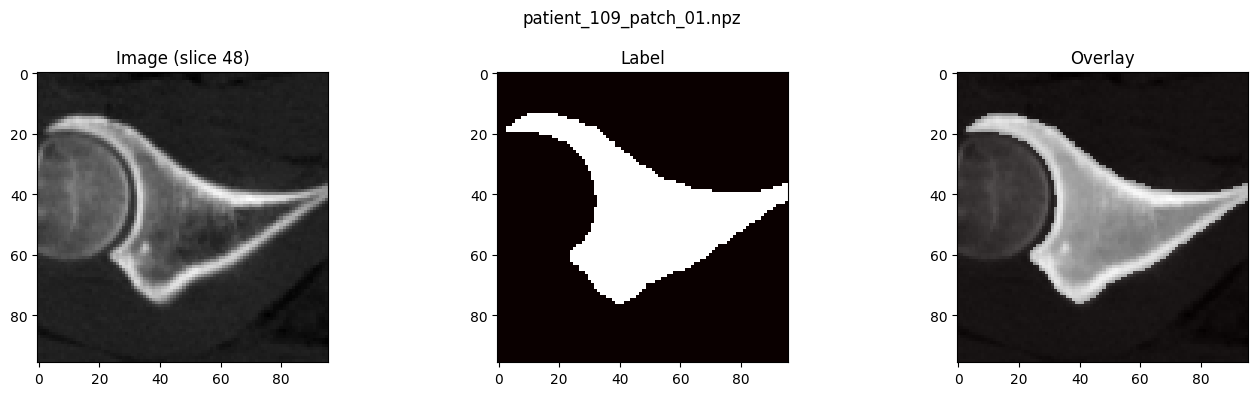


patient_123_patch_01.npz
  image shape : (1, 96, 96, 96)
  label shape : (1, 96, 96, 96)
  image min/max/mean : 0.000 / 1.000 / 0.157
  label unique values: [0 1 3]
  foreground voxels  : 48236 / 884736


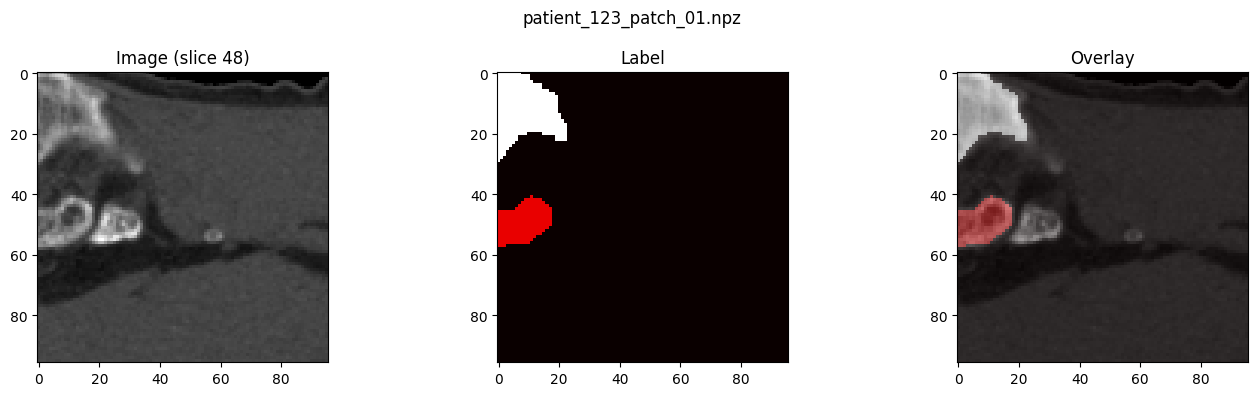


patient_066_patch_03.npz
  image shape : (1, 96, 96, 96)
  label shape : (1, 96, 96, 96)
  image min/max/mean : 0.000 / 1.000 / 0.174
  label unique values: [0 1 3]
  foreground voxels  : 174068 / 884736


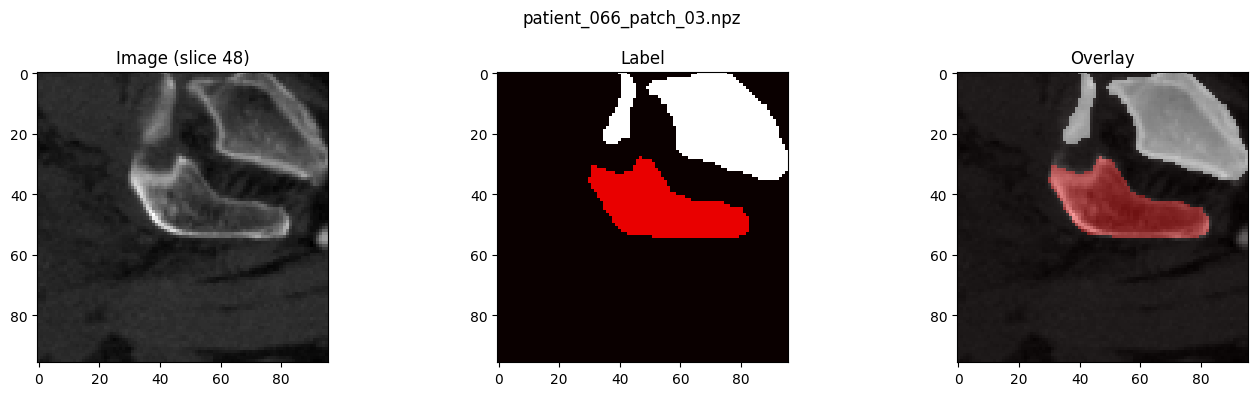


patient_079_patch_03.npz
  image shape : (1, 96, 96, 96)
  label shape : (1, 96, 96, 96)
  image min/max/mean : 0.000 / 0.943 / 0.167
  label unique values: [0 1 3]
  foreground voxels  : 187618 / 884736


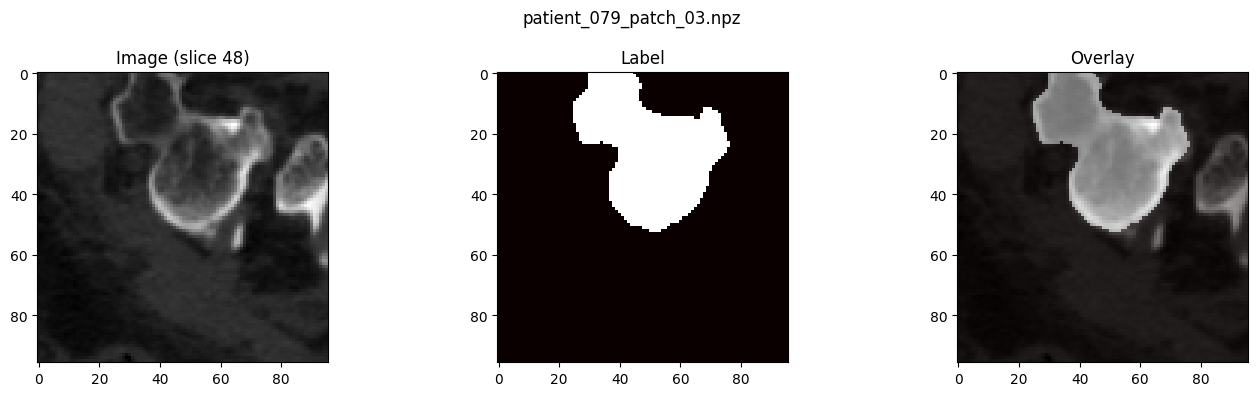


patient_026_patch_03.npz
  image shape : (1, 96, 96, 96)
  label shape : (1, 96, 96, 96)
  image min/max/mean : 0.000 / 1.000 / 0.116
  label unique values: [0 2]
  foreground voxels  : 66058 / 884736


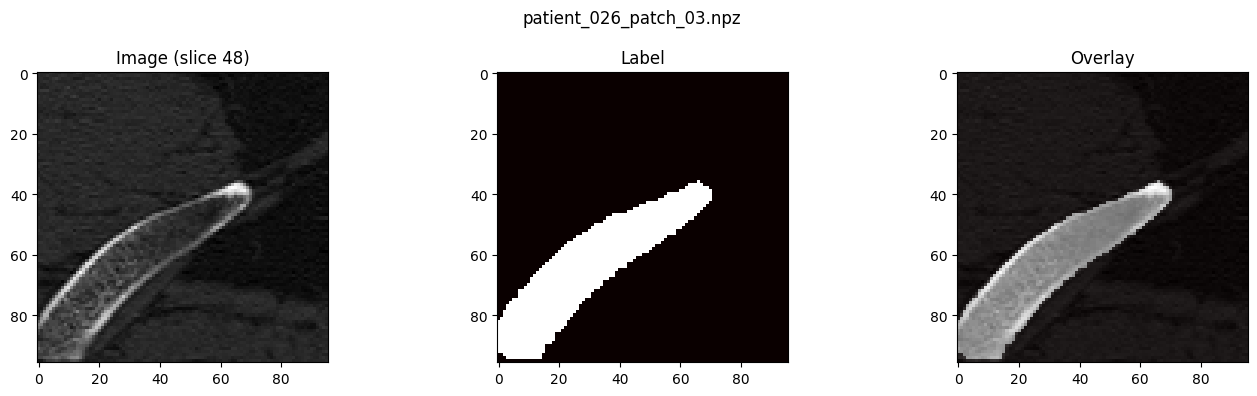

In [10]:
# 1. Check a few random patches
patch_files = sorted((PATCH_DIR).glob("*.npz"))
print(f"Total training patches: {len(patch_files)}")

for path in random.sample(patch_files, min(5, len(patch_files))):
    image, label = check_patch(path)
    visualise_patch(image, label, title=path.name)


Total validation volumes: 34

patient_156.npz
  image shape : (1, 400, 400, 280)
  label shape : (1, 400, 400, 280)
  image min/max/mean : 0.000 / 1.000 / 0.054
  label unique values: [0 1 2 3]
  foreground voxels  : 783316 / 44800000 (1.75%)


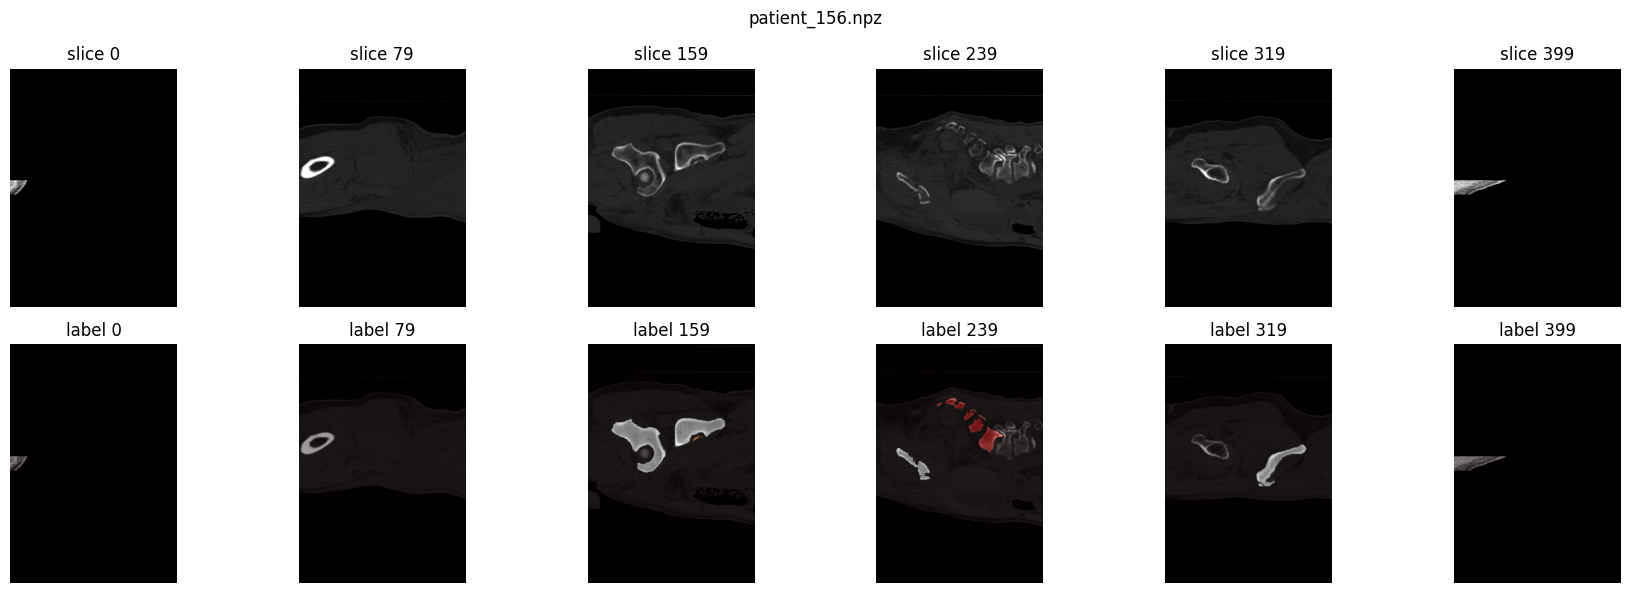


patient_165.npz
  image shape : (1, 411, 270, 311)
  label shape : (1, 411, 270, 311)
  image min/max/mean : 0.000 / 1.000 / 0.066
  label unique values: [0 1 2 3]
  foreground voxels  : 698506 / 34511670 (2.02%)


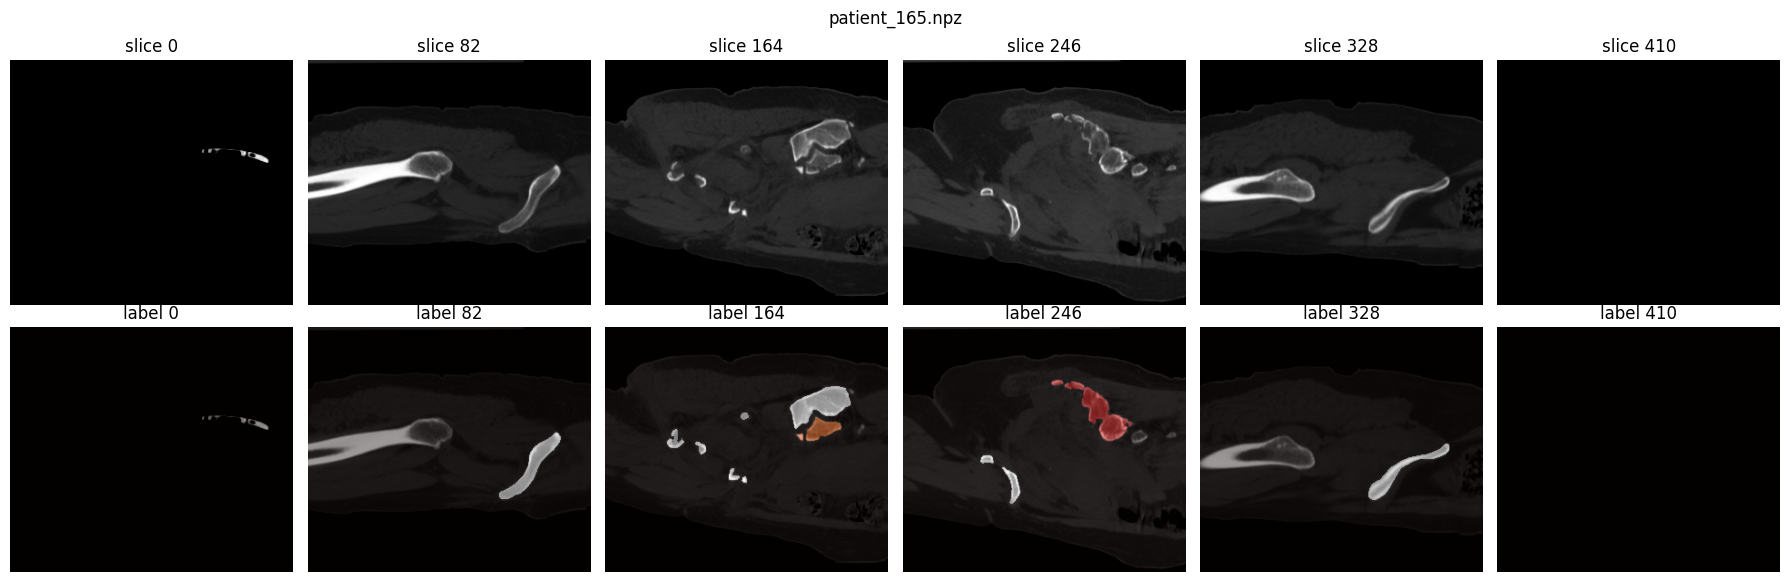


patient_151.npz
  image shape : (1, 281, 161, 217)
  label shape : (1, 281, 161, 217)
  image min/max/mean : 0.000 / 1.000 / 0.129
  label unique values: [0 1 2 3]
  foreground voxels  : 673213 / 9817297 (6.86%)


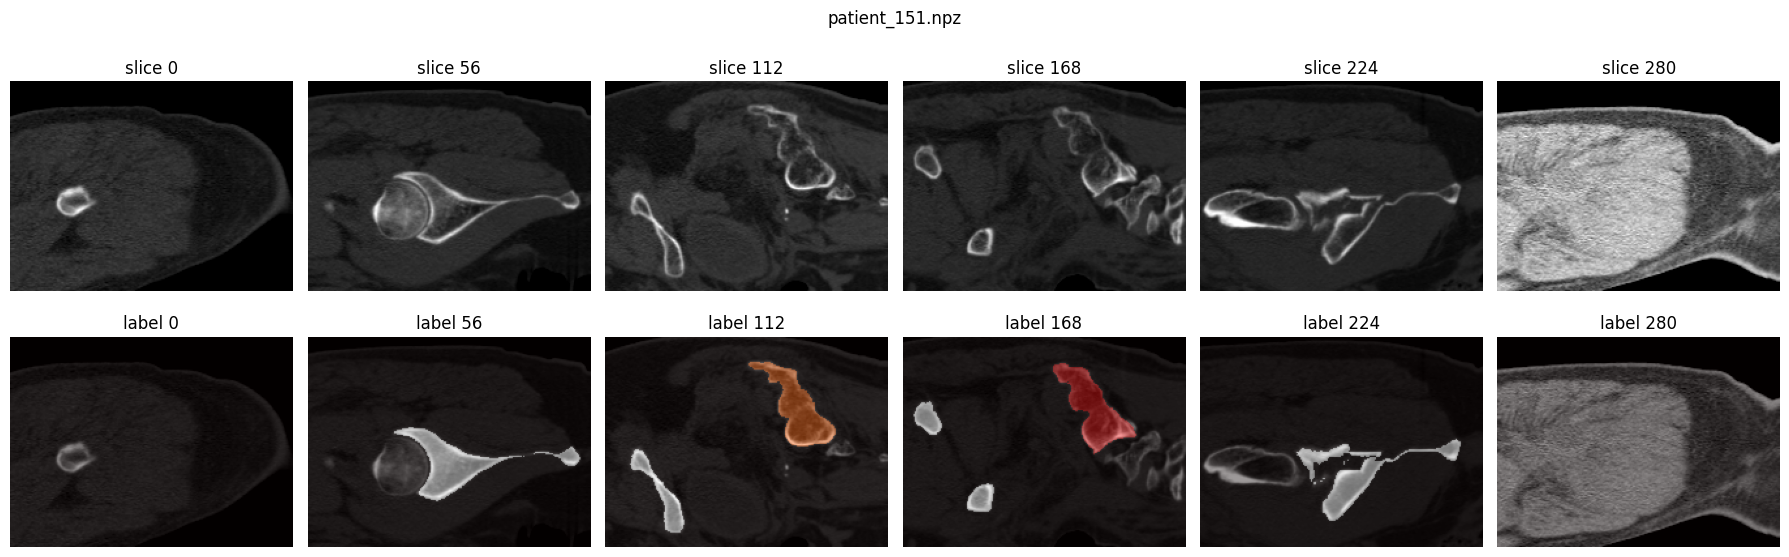

In [7]:
# 2. Check a few validation volumes
val_files = sorted((VAL_DIR).glob("*.npz"))
print(f"\nTotal validation volumes: {len(val_files)}")

for path in random.sample(val_files, min(3, len(val_files))):
    image, label = check_volume(path)
    visualise_volume_slices(image, label, title=path.name)